### Build a Basic Chatbot with LangGraph (GRAPH API)

#### Components of LangGraph

1. **Edges**

   * Connect one node to another
   * Decide the flow of execution

2. **Nodes**

   * Individual functions or tasks in the workflow
   * Perform operations like processing data or calling LLMs

3. **State**

   * Shared memory/data passed between nodes
   * Stores information during execution

---

#### LangGraph APIs

1. **Graph API**

   * Used to build workflows using nodes and edges visually/logically

2. **Functional API**

   * Used to create workflows using functions directly

---

#### Example Workflow

##### Flow:

`Transcript → Title Generator → Content Generator`

##### Explanation:

* **Transcript Node**
  Takes input transcript/text

* **Edge**
  Passes transcript to next node

* **Title Generator Node**
  Generates a title from transcript

* **Edge**
  Passes title + transcript forward

* **Content Generator Node**
  Generates final content/article

* **End**
  Workflow finishes after content generation


#### Reducers in LangGraph

Reducers define **how state updates are merged** when multiple nodes modify the same state field.

They help manage and combine data safely inside the graph.

---

#### Why Reducers are Needed

Without reducers:

* New values overwrite old values

With reducers:

* Values can be appended, merged, or combined intelligently

---

#### Common Reducer Example

##### `add_messages`

Used for chat/message history.

```python id="r2m8vx"
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]
```

##### What it does:

* Automatically appends new messages
* Preserves conversation history

---

#### Example Without Reducer

```python id="k7x1qp"
class State(TypedDict):
    messages: list
```

Problem:

* New messages replace old ones

---

#### Example With Reducer

```python id="m4v9tc"
class State(TypedDict):
    messages: Annotated[list, add_messages]
```

Result:

* Old + new messages are combined

---

#### Reducer Flow Example

Initial state:

```python id="f8z2ny"
{
    "messages": ["Hi"]
}
```

New update:

```python id="z3p6qw"
{
    "messages": ["How are you?"]
}
```

After reducer:

```python id="w5x8er"
{
    "messages": ["Hi", "How are you?"]
}
```

---

#### Custom Reducers

You can create your own reducer function.

```python id="n9k2lm"
def add_numbers(current, new):
    return current + new
```

Use it in state:

```python id="c4q7xt"
class State(TypedDict):
    numbers: Annotated[list[int], add_numbers]
```

---

#### Key Points

* Reducers control state merging
* Useful when multiple nodes update same key
* `add_messages` is the most commonly used reducer
* Custom reducers can be created for special logic


In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them).

    messages:Annotated[list, add_messages]       # hey append the messages to the list rather than replacing them

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [6]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "qwen/qwen3-32b",
    model_provider="groq"
)

llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014BDA9E5E10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014BDAB46190>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Node Functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}    # state of messages is my input message, llm will priovide the response for this and append it in our messages variable

In [8]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot" , chatbot)     # ("node_name" , node_implementation)

## Adding edges
graph_builder.add_edge(START , "llmchatbot")       # we are going from start -> node (i.e. llmchatbot here , specify the node name here)
graph_builder.add_edge("llmchatbot" , END)

## Compile the graph
graph = graph_builder.compile()

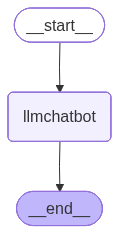

In [9]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages": "Hi"})

In [11]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond politely. Let me check the guidelines. I need to be friendly and offer help. Maybe say something like "Hello! How can I assist you today?" That should work. Keep it simple and open-ended. Make sure to use an emoji to keep the tone positive. Yeah, that sounds good.\n</think>\n\nHello! 😊 How can I assist you today?'

In [12]:
## Streaming
for event in graph.stream({"messages": "Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with a friendly question. I need to respond in a warm and friendly manner. I should first acknowledge their greeting, then ask about their day, and offer assistance. Keep it simple and natural. Let me make sure my response is welcoming and open-ended to encourage them to share more if they want.
</think>

Hi there! I'm doing great, thank you for asking! How about you? I hope your day is going well. If you have any questions or need help with anything, feel free to let me know! 😊


### Chatbot with Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [14]:
## Custom Function
def multiply(a: int, b: int) -> int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a*b

In [15]:
tools = [tool , multiply]

In [16]:
llm_with_tool = llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014BDA9E5E10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014BDAB46190>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real

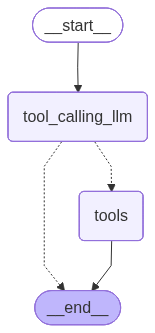

In [18]:
## State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

## Node Definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm" , tool_calling_llm)
builder.add_node("tools" , ToolNode(tools))

## Add Edges
builder.add_edge(START , "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

    # If the latest message (result) from assistant is a tool call
    # -> tools_condition routes to tools

    # If the latest message (result) from assistant is not a tool call
    # -> tools_condition routes to END

    tools_condition
)

builder.add_edge("tools" , END)

## Compile the graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages": "What is the recent AI news?"})

In [20]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Sendbird launched Agent Steward to provide autonomy in customer experiences. The product allows businesses to deploy AI agents that manage support interactions without constant human intervention. The tool focuses on ownership and control over the brand’s automated communication.\\n\\nShout Digital released a content gap tool to increase client visibility. The AI-driven tool identifies topics that competitors cover but the client does not. This information helps brands create content that satisfies the requirements of search and AI results. [...] Rakuten Advertising launched Mirai as an optimization agent for affiliate marketing. The AI agent manages campaign performance by identifying high-value partnerships and traffic sources. The tool 

In [21]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (st89jv8qr)
 Call ID: st89jv8qr
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Sendbird launched Agent Steward to provide autonomy in customer experiences. The product allows businesses to deploy AI agents that manage support interactions without constant human intervention. The tool focuses on ownership and control over the brand’s automated communication.\n\nShout Digita

In [22]:
response = graph.invoke({"messages": "What is the 2 multiplied by 3?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (jzfb5jakk)
 Call ID: jzfb5jakk
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [23]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (g1qgvkrzw)
 Call ID: g1qgvkrzw
  Args:
    query: recent AI news
    time_range: day
  multiply (8jk95dxy0)
 Call ID: 8jk95dxy0
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/video/wedbushs-ives-ai-rally-spacex-024423187.html", "title": "Wedbush's Ives on AI Rally, SpaceX IPO", "content": "Dan Ives, Global Head of Technology Research at Wedbush Securities, discusses the revival of the AI trade and looks ahead to the listings of OpenAI,", "score": 0.38435796, "raw_content": null}, {"url": "https://www.haystack.tv/v/trump-signs-order-

### ReAct Agent Architecture

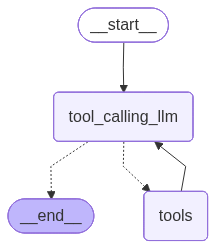

In [24]:
from IPython.display import Image, display

## Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }


## Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",

    # If assistant response contains a tool call
    # -> go to tools node

    # Otherwise
    # -> go to END

    tools_condition
)

# After tool execution, go back to LLM
builder.add_edge("tools", "tool_calling_llm")


## Compile graph
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
response = graph.invoke({"messages": "Give me the recent AI news and then multiply 5 by 10?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent AI news and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hqv1rq1sx)
 Call ID: hqv1rq1sx
  Args:
    query: recent AI news
    time_range: day
  multiply (9myzt3q5m)
 Call ID: 9myzt3q5m
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wsj.com/tech/ai", "title": "Artificial Intelligence - Latest AI News and Analysis - WSJ.com", "content": "Google Seeks $80 Billion for AI Buildout; Berkshire Will Buy $10 Billion Stake · The company says it will use the money to finance data-center expansion and", "score": 0.7166357, "raw_content": null}, {"url": "https://www.instagram.com/p/DZH8aIuiKUn", "title": "AI • Tech

### Adding Memory in Agentic Graph

In [26]:
response = graph.invoke({"messages": "Hello my name is Deepak"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Deepak
================================== Ai Message ==================================

Hello Deepak! How can I assist you today?


In [26]:
response = graph.invoke({"messages": "What is my name?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have access to personal information about users. Would you like me to help you with something else?


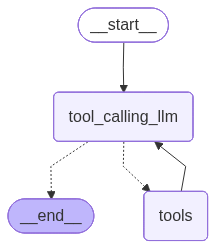

In [27]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }


## Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges
builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",

    # If assistant response contains a tool call
    # -> go to tools node

    # Otherwise
    # -> go to END

    tools_condition
)

# After tool execution, go back to LLM
builder.add_edge("tools", "tool_calling_llm")


## Compile graph
graph = builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
config={"configurable": {"thread_id":"1"}}

response = graph.invoke({"messages": "Hi, my name is Deepak"}, config)

response

{'messages': [HumanMessage(content='Hi, my name is Deepak', additional_kwargs={}, response_metadata={}, id='1b9e077e-1b93-4546-b7a5-ee884e75e763'),
  AIMessage(content='Hi Deepak! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user said, "Hi, my name is Deepak." That\'s a greeting and they introduced themselves. I need to respond appropriately.\n\nFirst, I should acknowledge their greeting. A simple "Hello" or "Hi" would work. Then, offer assistance. Since they mentioned their name, maybe include it in the response to make it personal. Like, "Hi Deepak! How can I assist you today?"\n\nLooking at the tools provided, there\'s a search function and a multiply function. But the user hasn\'t asked for anything that requires a tool yet. They just introduced themselves, so probably no need to call any functions right now. Just a friendly response to start the conversation. Make sure to keep it open-ended so they know I\'m here to help with whateve

In [32]:
response['messages'][-1].content

'Hi Deepak! How can I assist you today?'

In [34]:
response = graph.invoke({"messages": "Hey, what is my name?"}, config)

print(response['messages'][-1].content)

Your name is still Deepak! 😊 How can I assist you today?


### Streaming in Langgraph

In [1]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [27]:
def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

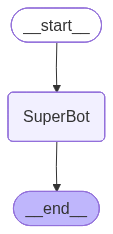

In [31]:
graph = StateGraph(State)

## Node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

## Display
from IPython.display import Image, display

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [32]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke(
    {
        "messages": "Hi, My name is Deepak And I like cricket"
    },
    config=config
)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='c10f183b-06d5-4103-a910-c65cffafe2c4'),
  AIMessage(content='<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. Let me start by acknowledging their name and expressing enthusiasm about their interest in cricket. I should ask a follow-up question to engage them more. Maybe ask which team they support or if they play the game. That way, I can keep the conversation going and learn more about their preferences. I need to make sure the response is friendly and open-ended. Also, keep the tone positive and welcoming. Let me check for any typos and ensure the questions are clear. Alright, that should work.\n</think>\n\nHi Krish! Nice to meet you. 🏏 I know cricket is an amazing sport—do you have a favorite team or player? Also, do you play cricket yourself, or are you more of a passionate fan watching matches? Let me know, and we can 

Streaming

Methods: `.stream()` and `astream()`

* These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

* `values` : This streams the full state of the graph after each node is called.
* `updates` : This streams updates to the state of the graph after each node is called.

In [33]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config,
    stream_mode="updates"
):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Krish and he likes cricket. Let me start by acknowledging his name and showing interest in his hobby. I should ask him how he got into cricket to keep the conversation going. Maybe he plays the game or just watches it. I can ask about his experience. Also, I should find out which team or players he supports. It might be a local team or a national team. I should ask about his favorite players, maybe their playing style or achievements. Maybe he follows specific tournaments like the World Cup or T20. I can ask if he prefers a particular format of the game. Also, it might be good to ask if he plays cricket and what position he plays. If he does, that's interesting to know. If not, maybe he enjoys watching it. I should keep the conversation open and friendly, not too many questions at once. Let me start with a friendly greeting and then ask a few questions to get more details.\n</think>\n\nHi Krish! Nice to meet you! 

In [34]:
for chunk in graph_builder.stream(
    {"messages": "Hi, My name is Krish And I like cricket"},
    config,
    stream_mode="values"
):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='8ad0b445-0ec9-4a01-aa7c-ea5d181dffb3'), AIMessage(content="<think>\nOkay, the user is Krish and he likes cricket. Let me start by acknowledging his name and showing interest in his hobby. I should ask him how he got into cricket to keep the conversation going. Maybe he plays the game or just watches it. I can ask about his experience. Also, I should find out which team or players he supports. It might be a local team or a national team. I should ask about his favorite players, maybe their playing style or achievements. Maybe he follows specific tournaments like the World Cup or T20. I can ask if he prefers a particular format of the game. Also, it might be good to ask if he plays cricket and what position he plays. If he does, that's interesting to know. If not, maybe he enjoys watching it. I should keep the conversation open and friendly, not too many questions

In [35]:
config = {"configurable": {"thread_id": "4"}}

async for event in graph_builder.astream_events(
    {"messages": ["Hi my name is Krish and I like to play cricket"]},
    config,
    version="v1"
):
    print(event)

c:\Agentic AI\Agentic_AI_Course\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3746: LangChainDeprecationWarning: astream_events version='v1' is deprecated. Use version='v2' or astream instead.
  await eval(code_obj, self.user_global_ns, self.user_ns)


{'event': 'on_chain_start', 'run_id': '019e8e66-6b1f-7b23-a374-835eaf4b56f3', 'name': 'LangGraph', 'tags': [], 'metadata': {}, 'data': {'input': {'messages': ['Hi my name is Krish and I like to play cricket']}}, 'parent_ids': []}
{'event': 'on_chain_start', 'name': 'SuperBot', 'run_id': '019e8e66-6b25-7a91-8bdd-e39fe083101a', 'tags': ['graph:step:1'], 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:806aa393-d692-9214-27d4-96f5c1abb36c'}, 'data': {'input': {'messages': [HumanMessage(content='Hi my name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='fa4e70c2-407f-48c9-a004-dccd6d37b24e')]}}, 'parent_ids': []}
{'event': 'on_chat_model_start', 'name': 'ChatGroq', 'run_id': '019e8e66-6b28-7722-832e-566cc63a6e48', 'tags': ['seq:step:1'], 'metadata': {'thread_